In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
df = pd.read_excel('/content/messy_sales_dataset.xlsx')

In [17]:
df.isnull().sum()

,0
Order_ID,0
Date,0
Region,0
Product,0
Category,0
Units_Sold,1705
Unit_Price,1265
Discount_%,848
Marketing_Spend,1652
Customer_Rating,2636


In [18]:
df.duplicated().sum()

np.int64(100)

In [20]:
df["Date"] = pd.to_datetime(
    df["Date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

In [22]:
df["Date"].isnull().sum()

np.int64(0)

In [24]:
df = df.drop_duplicates().copy()

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df.isnull().sum()

,0
Order_ID,0
Date,0
Region,0
Product,0
Category,0
Units_Sold,1661
Unit_Price,1238
Discount_%,833
Marketing_Spend,1611
Customer_Rating,2576


In [28]:
df["Region"] = df["Region"].str.strip().str.title()

In [30]:
df.isnull().sum()

,0
Order_ID,0
Date,0
Region,0
Product,0
Category,0
Units_Sold,1661
Unit_Price,1238
Discount_%,833
Marketing_Spend,1611
Customer_Rating,2576


In [31]:
df["Product"] = df["Product"].str.strip().str.title()

In [32]:
df["Product"].unique()

array(['Keyboard', 'Laptop', 'Monitor', 'Mouse', 'Tablet', 'Phone'],
      dtype=object)

In [33]:
df["Category"] = df["Category"].str.strip().str.title()

In [34]:
df["Category"] = df["Category"].replace({
    "Electroncs": "Electronics",
    "Electrnics": "Electronics",
    "electronics": "Electronics"
})

In [35]:
df["Category"].unique()

array(['Accessories', 'Electronics', 'Office'], dtype=object)

In [36]:
print("Units_Sold:", (df["Units_Sold"] < 0).sum())
print("Unit_Price:", (df["Unit_Price"] < 0).sum())
print("Marketing_Spend:", (df["Marketing_Spend"] < 0).sum())

Units_Sold: 1671
Unit_Price: 1247
Marketing_Spend: 1692


In [37]:
df.loc[df["Units_Sold"] < 0, "Units_Sold"] = np.nan

df.loc[df["Unit_Price"] < 0, "Unit_Price"] = np.nan

df.loc[df["Marketing_Spend"] < 0, "Marketing_Spend"] = np.nan

In [38]:
df["Discount_%"] = df["Discount_%"].fillna(df["Discount_%"].median())

df["Customer_Rating"] = df["Customer_Rating"].fillna(df["Customer_Rating"].median())

df["Units_Sold"] = df["Units_Sold"].fillna(df["Units_Sold"].median())

df["Unit_Price"] = df["Unit_Price"].fillna(df["Unit_Price"].median())

df["Marketing_Spend"] = df["Marketing_Spend"].fillna(df["Marketing_Spend"].median())

In [40]:
df["Revenue"] = (
    df["Units_Sold"] *
    df["Unit_Price"] *
    (1 - df["Discount_%"] / 100)
)

In [42]:
df.isnull().sum()

,0
Order_ID,0
Date,0
Region,0
Product,0
Category,0
Units_Sold,0
Unit_Price,0
Discount_%,0
Marketing_Spend,0
Customer_Rating,0


In [44]:
df.to_excel("cleaned_sales_data.xlsx", index=False)

In [45]:
from google.colab import files

files.download("cleaned_sales_data.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# EXPLORATORY DATA ANALYSIS (EDA)

In [46]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Quarter"] = df["Date"].dt.quarter
df["Day_of_Week"] = df["Date"].dt.day_name()

In [49]:
print("Total Revenue:", df["Revenue"].sum())

Total Revenue: 1378987169.2


In [50]:
print("Average Revenue:", df["Revenue"].mean())

Average Revenue: 275797.43384


In [51]:
region_sales = df.groupby("Region")["Revenue"].sum()

print(region_sales)

Region
East     198972925.8
North    479584963.3
South    462499732.4
West     237929547.7
Name: Revenue, dtype: float64


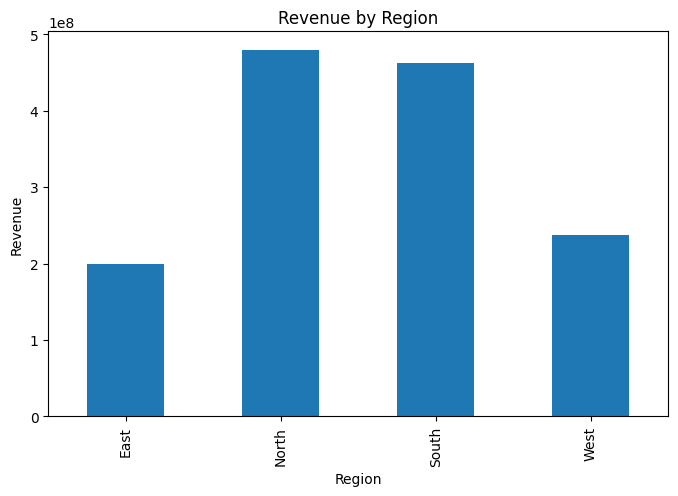

In [52]:
plt.figure(figsize=(8,5))

region_sales.plot(kind="bar")

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")

plt.show()

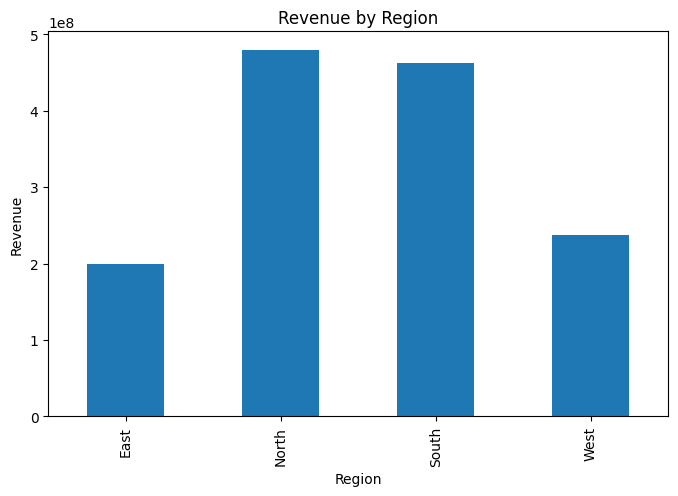

In [53]:
plt.figure(figsize=(8,5))

region_sales.plot(kind="bar")

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")

plt.savefig("region_sales.png")

plt.show()

In [55]:
monthly_sales = df.groupby("Month")["Revenue"].sum()

print(monthly_sales)

Month
1     1.411078e+08
2     1.373081e+08
3     1.241649e+08
4     1.500661e+08
5     1.415384e+08
6     1.270685e+08
7     9.731382e+07
8     9.623855e+07
9     9.629558e+07
10    9.576866e+07
11    7.916934e+07
12    9.294743e+07
Name: Revenue, dtype: float64


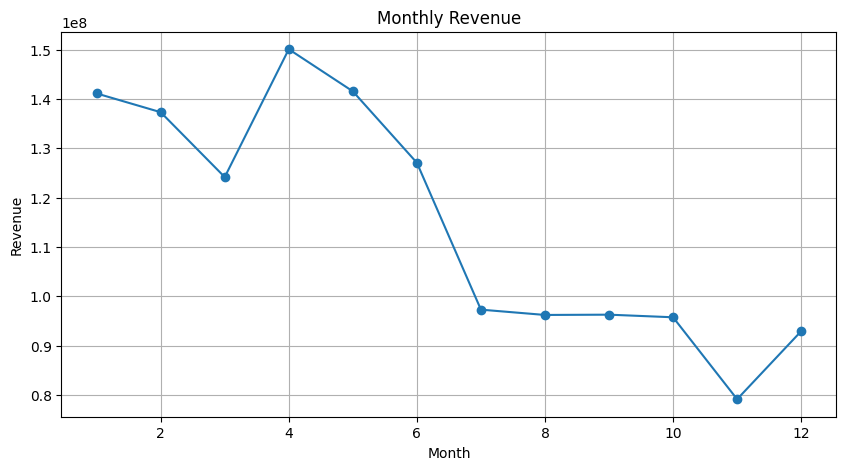

In [56]:
plt.figure(figsize=(10,5))

monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)

plt.show()

In [58]:
product_sales = df.groupby("Product")["Revenue"].sum()

print(product_sales)

Product
Keyboard    1.877756e+08
Laptop      5.235936e+08
Monitor     1.568032e+08
Mouse       1.746188e+08
Phone       1.654687e+08
Tablet      1.707273e+08
Name: Revenue, dtype: float64


In [59]:
top5 = product_sales.sort_values(ascending=False).head(5)

print(top5)

Product
Laptop      5.235936e+08
Keyboard    1.877756e+08
Mouse       1.746188e+08
Tablet      1.707273e+08
Phone       1.654687e+08
Name: Revenue, dtype: float64


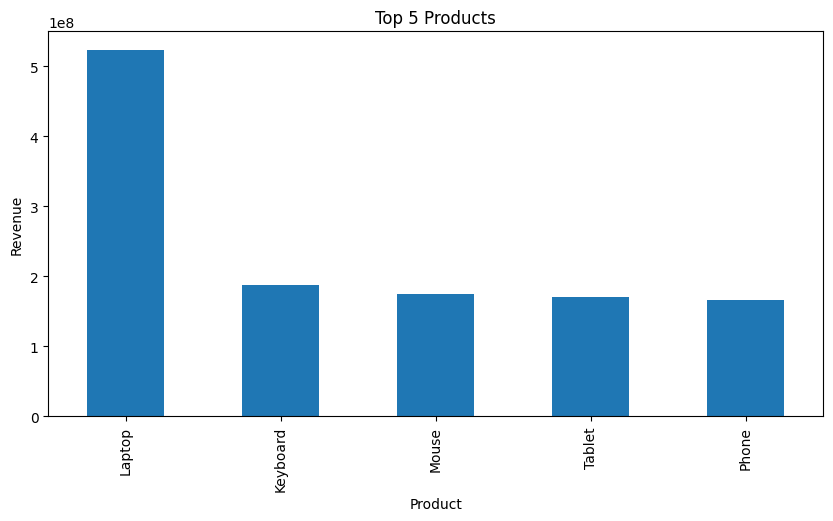

In [60]:
plt.figure(figsize=(10,5))

top5.plot(kind="bar")

plt.title("Top 5 Products")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.show()

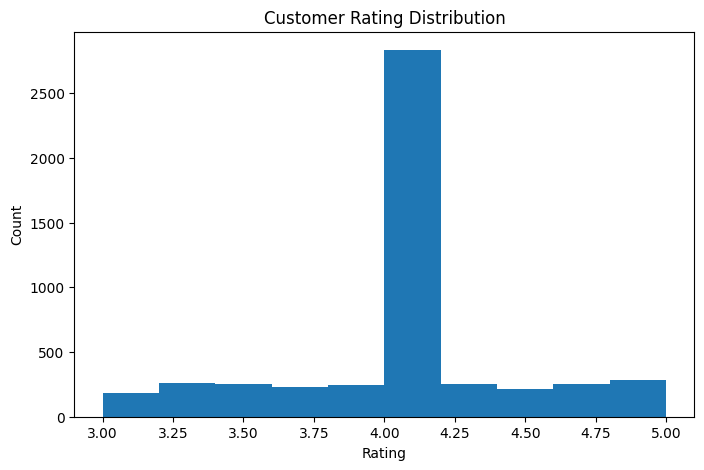

In [61]:
plt.figure(figsize=(8,5))

plt.hist(df["Customer_Rating"], bins=10)

plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

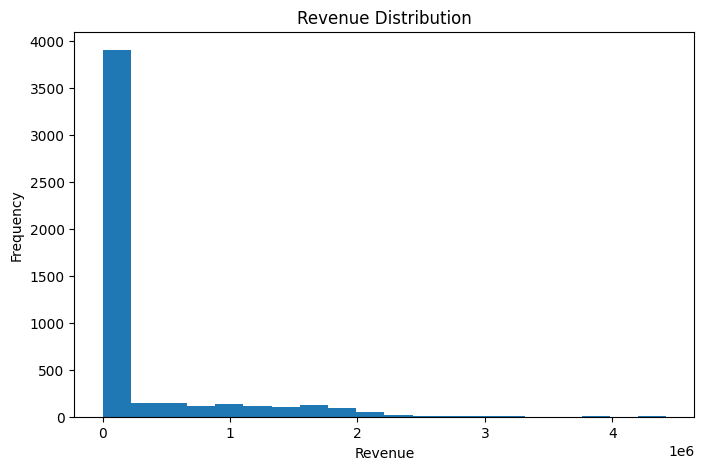

In [62]:
plt.figure(figsize=(8,5))

plt.hist(df["Revenue"], bins=20)

plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.show()

In [63]:
df.to_excel("cleaned_sales_data.xlsx", index=False)

In [ ]:
# Machine Learning (Linear Regression)

In [64]:
features = [
    "Units_Sold",
    "Unit_Price",
    "Discount_%",
    "Marketing_Spend",
    "Customer_Rating",
    "Month",
    "Quarter",
    "Year"
]

X = df[features]
y = df["Revenue"]

In [ ]:
# Split the Dataset

In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [66]:
print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (4000, 8)
Testing Data : (1000, 8)


In [67]:
from sklearn.linear_model import LinearRegression

In [68]:
model = LinearRegression()

In [69]:
model.fit(X_train, y_train)

LinearRegression()

In [70]:
y_pred = model.predict(X_test)

In [71]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", mae)
print("Mean Squared Error  :", mse)
print("Root Mean Squared Error :", rmse)
print("R² Score :", r2)

Mean Absolute Error : 94469.21363622985
Mean Squared Error  : 47772411844.98016
Root Mean Squared Error : 218569.0093425419
R² Score : 0.8615778211588537


In [72]:
results = pd.DataFrame({
    "Actual Revenue": y_test,
    "Predicted Revenue": y_pred
})

results.head(10)

,Actual Revenue,Predicted Revenue
1501,25167.40,1.997491e+04
2586,0.00,-2.407129e+04
2653,0.00,1.731961e+04
1055,707196.00,1.639302e+06
705,22339.20,-1.034070e+04
106,22339.20,-6.454573e+03
589,65726.70,8.190188e+04
2468,27924.00,5.068401e+04
2413,22339.20,-3.018269e+03
1600,788620.65,7.980463e+05


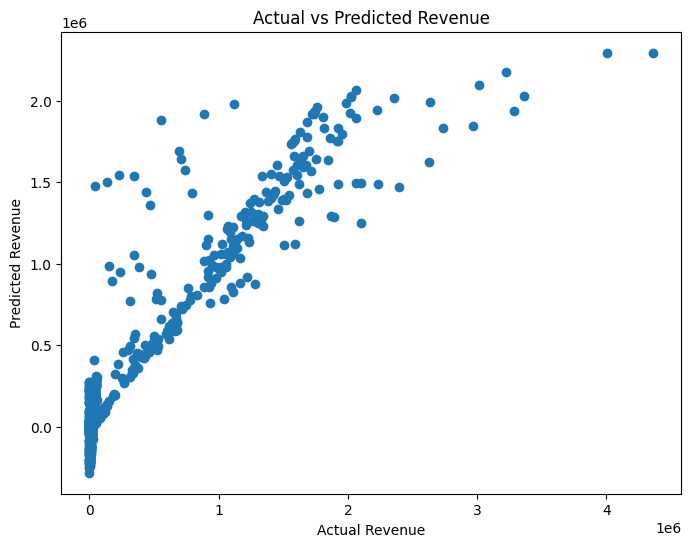

In [73]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.title("Actual vs Predicted Revenue")
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")

plt.show()

In [77]:
import joblib

joblib.dump(model, "linear_regression_model.pkl")

['linear_regression_model.pkl']

In [79]:
results.to_excel("prediction_results.xlsx", index=False)

In [81]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
4,Customer_Rating,7347.141731
0,Units_Sold,6606.951163
7,Year,986.732954
5,Month,450.382104
1,Unit_Price,35.226425
3,Marketing_Spend,0.335346
6,Quarter,-2214.989108
2,Discount_%,-2840.554411
